# RAG in context

A refresher on retrieval-augmented generation, written to connect it to ideas that have
been around a lot longer. RAG shows up in a great many job descriptions, and most of what
makes it work turns out to be search, which is a well-worn subject.

Everything here runs on a laptop with no account and no API key. Two small models download
once and then it works offline.

## The problem

Somewhere in a company wiki, a support archive, or a codebase nobody has read end to end,
there is a paragraph that answers your question. Two things stand between you and it.

**Keyword search makes you guess the author's words.** Search "wipe the database" and you
will miss the file that says `make reset`.

**A language model has never seen those documents.** Pasting them all into the prompt is
the obvious fix, and it stops working as soon as the documents outgrow the context window.

So: find the few paragraphs most likely to answer the question, and paste only those. That
finding step is retrieval, and it is where nearly all the engineering lives.

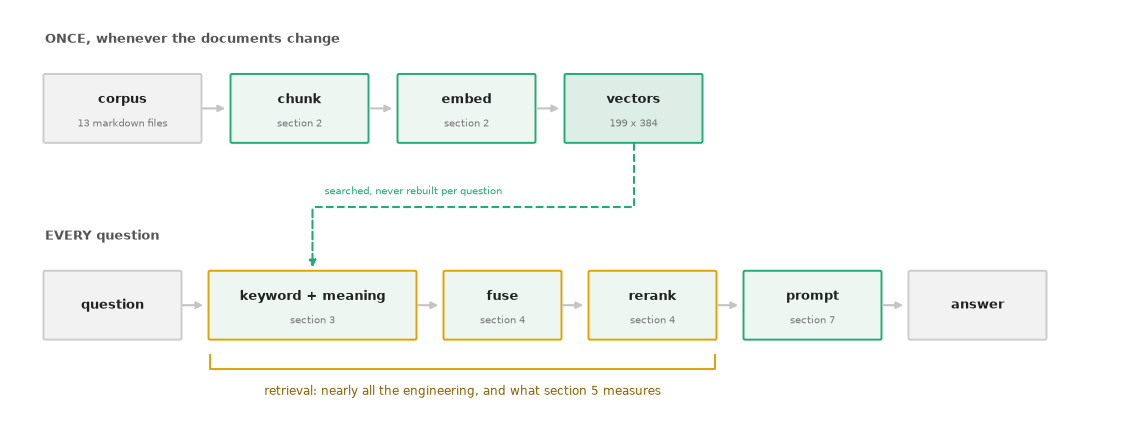

In [1]:
import figures

figures.pipeline()

Two loops, and keeping them apart is most of understanding RAG. The top row runs once,
whenever the documents change. The bottom row runs for every question asked.

## 1. Where this sits in the ML you already know

Worth placing before going further, because the name suggests more novelty than there is.

**RAG involves no training.** It is an architecture: search, then paste into a prompt. That
is exactly why it caught on, since it gives a model access to your documents without the
cost and risk of fine-tuning one. The rough rule is that fine-tuning teaches a model new
*behaviour*, and retrieval gives it new *facts*. Plenty of people reaching for the first
want the second.

**The pieces sit in familiar categories.** Keyword search does not learn at all; it is
arithmetic over word counts, and the version here dates to the 1990s. The embedding model
is deep learning, pretrained on a large corpus and then tuned on sentence pairs. The
reranker in section 4 is ordinary supervised learning, trained on labelled pairs of
queries and documents.

**And the core operation is one you have already used.** Represent things as vectors,
compare them with a cosine. That is decades old. What changed is where the numbers come
from, which is the subject of the next section.

## 2. From text to vectors

Retrieval returns pieces of documents rather than whole files, because a whole file is
usually too big for the prompt and too broad to match a question. So the documents get cut
up first. Cut too small and a piece loses the context that made it mean something; cut too
large and it covers several topics at once.

The split below goes on markdown headings first, since a heading is the author's own mark
for where one idea ends, then hard-wraps anything still too long. Section 6 comes back to
what that choice costs.

In [2]:
import re, pathlib
import numpy as np
import figures
from collections import Counter

CORPUS = pathlib.Path("corpus")
# Paths here are relative, so the notebook has to run from the repo root. Say so
# clearly rather than failing later with an empty-corpus error.
assert CORPUS.is_dir(), f"no corpus/ found from {pathlib.Path.cwd()} - run from the repo root"

def split_sections(text):
    # Split before a heading, so each piece keeps its own heading as a title.
    return [p.strip() for p in re.split(r"\n(?=#{1,3} )", text) if p.strip()]

def window(section, max_chars, overlap):
    # Overlap so a fact sitting on a cut line survives in at least one chunk whole.
    if len(section) <= max_chars:
        return [section]
    out, start = [], 0
    while start < len(section):
        out.append(section[start:start + max_chars])
        start += max_chars - overlap
    return out

def build_chunks(max_chars=900, overlap=150):
    chunks = []
    for path in sorted(CORPUS.glob("*.md")):
        for section in split_sections(path.read_text()):
            for piece in window(section, max_chars, overlap):
                chunks.append({"repo": path.name.split("__")[0],
                               "file": path.name,
                               "text": piece})
    return chunks

chunks = build_chunks()
print(f"{len(chunks)} chunks from {len(list(CORPUS.glob('*.md')))} files")
print(f"median length: {int(np.median([len(c['text']) for c in chunks]))} chars")

199 chunks from 13 files
median length: 396 chars


*In production:* `RecursiveCharacterTextSplitter` from LangChain, or the node parsers in
LlamaIndex. Both do this and handle the short leftover piece at the end, which the version
above does not.

Now the part that is genuinely new. Classical text search represents a document as counts
of the words in it, so the coordinates are words you chose. An **embedding** model produces
the coordinates instead: a fixed-length list of numbers for any span of text, arranged so
that text with similar meaning lands in a similar direction.

`all-MiniLM-L6-v2` is a small one: 6 layers, 22M parameters, about 90 MB. It is a
transformer, as is the reranker in section 4 and as is nearly every LLM in current use.
What differs across them is size and what they were trained to emit, vectors here and text
there.

In [3]:
from transformers.utils import logging as hf_logging
from sentence_transformers import SentenceTransformer

# Loading the model prints a progress bar that freezes at 0% in a saved notebook.
# transformers ships with sentence-transformers, so this costs no extra dependency.
hf_logging.disable_progress_bar()

encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def embed(texts):
    return encoder.encode(texts, normalize_embeddings=True, batch_size=64,
                          show_progress_bar=False)

E = embed([c["text"] for c in chunks])
print("E:", E.shape, "->", E.shape[0], "chunks x", E.shape[1], "numbers each")
print("every row has length 1:", np.allclose(np.linalg.norm(E, axis=1), 1.0))

E: (199, 384) -> 199 chunks x 384 numbers each
every row has length 1: True


*In production:* a hosted embedding API such as Voyage, OpenAI or Cohere, or a larger open
model like `bge` or `e5`. More dimensions generally means better matching and more storage.

That matrix is `E`, and every search in this notebook is something done to it. Each row is
scaled to length 1, which matters for a practical reason. For unit vectors the dot product
*is* the cosine of the angle between them, so comparing two chunks is one multiplication
rather than a formula.

Which means the geometry is the geometry you already know. Below, one chunk is the
reference, and four others are drawn at the angle the model actually produced.

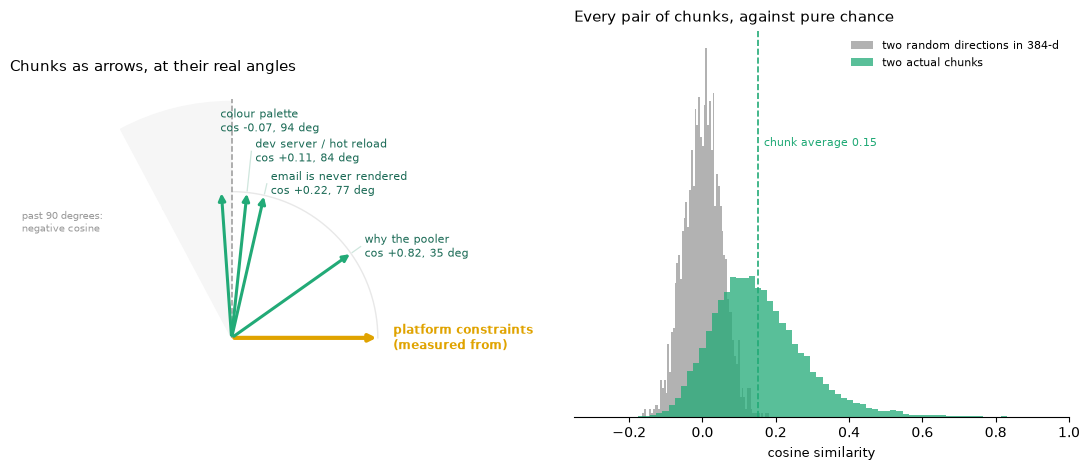

In [4]:
ref = next(k for k, c in enumerate(chunks) if "No persistent volumes" in c["text"])

others = {
    "why the pooler":          "Why the pooler",
    "email is never rendered": "never rendered",
    "dev server / hot reload": "hot module reload",
    "colour palette":          "Color Palette",
}
picked = {name: next(k for k, c in enumerate(chunks) if m in c["text"])
          for name, m in others.items()}

figures.cosine_fan("platform constraints", list(picked),
                   [float(E[ref] @ E[k]) for k in picked.values()], E)

Two passages about infrastructure sit 35 degrees apart, and nobody told the model they came
from the same project. A colour palette sits past 90 degrees, which is what a negative
cosine means.

The right-hand panel is the part that changes how to read every score here. Two random
directions in 3 dimensions can be at any angle, but two random directions in 384 dimensions
are almost always near 90 degrees, which is the grey pile at 0. Real chunks average 0.15
rather than 0, because they share a great deal before you reach their topic: English,
software, markdown, one person's habits.

So a cosine of 0.45 is a strong match here while sounding like a weak one. Scores mean
something relative to other scores for the same question, which makes a fixed similarity
threshold a shaky way to decide whether to answer.

## 3. Two ways to search

With `E` built, searching by meaning is one line: score the question against every chunk
and keep the best few.

In [5]:
def dense_scores(query):
    q = embed([query])[0]
    return E @ q          # cosine against every chunk at once, because rows are unit length

def top_k(scores, k=5):
    # argsort returns the indices that *would* sort the array, not the sorted values.
    # It sorts ascending, so negating flips it to descending.
    return np.argsort(-scores)[:k]

demo = "why does the app avoid writing files to local disk?"
for rank, i in enumerate(top_k(dense_scores(demo), 3), 1):
    flat = " ".join(chunks[i]["text"].split())
    print(f"{rank}. {dense_scores(demo)[i]:.3f}  {chunks[i]['file']}")
    print(f"   {flat[:88]}...")

1. 0.336  secondhandplastic__SECURITY.md
   path that stores an original file unaltered is a high-severity issue. 4. **Messages are ...
2. 0.297  secondhandplastic__SECURITY.md
   ## What this project promises its users These are the guarantees a vulnerability report ...
3. 0.290  secondhandplastic__CLAUDE.md
   ## Platform constraints that shape the code - **No persistent volumes.** Anything writte...


*In production:* a vector database. `E @ q` is the whole comparison; a vector store adds
persistence, metadata filters, and an index that finds approximately the nearest vectors
without scanning all of them, which starts to matter around a hundred million rows. If you
have used **pgvector**, `ORDER BY embedding <=> $1` is doing this same cosine, with the
vectors sitting beside your relational data so scoping a search is a `WHERE` clause.

The other way to search is by keyword, and the standard is **BM25**. It scores a chunk by
the query words it literally contains, weighted by two ideas. **Term frequency**: a chunk
mentioning "postgres" five times beats one mentioning it once. **Inverse document
frequency**: a word appearing in every chunk tells you nothing, so "the" is worthless and a
rare token like a port number is valuable.

It is written out here rather than imported because the frequency table is worth seeing.

In [6]:
import math

def tokenize(s):
    return re.findall(r"[a-z0-9]+", s.lower())

def index_bm25(chunks):
    # Every statistic here depends on how the corpus was chunked, so this has to be
    # rebuilt whenever the chunking changes. Section 6 shows why that matters.
    global docs, N, avgdl, tf, df, idf
    docs  = [tokenize(c["text"]) for c in chunks]
    N     = len(docs)
    avgdl = sum(len(d) for d in docs) / N
    tf    = [Counter(d) for d in docs]
    df    = Counter(t for d in docs for t in set(d))
    idf   = {t: math.log(1 + (N - n + 0.5) / (n + 0.5)) for t, n in df.items()}

index_bm25(chunks)

def bm25_scores(query, k1=1.5, b=0.75):
    # k1 damps repeated words so the 20th "postgres" adds little over the 3rd, and b
    # penalises long chunks so they cannot win just by being big. Standard defaults.
    scores = np.zeros(N)
    for term in tokenize(query):
        if term not in idf:
            continue
        for i in range(N):
            f = tf[i][term]
            if f:
                dl = len(docs[i])
                scores[i] += idf[term] * f * (k1 + 1) / (f + k1 * (1 - b + b * dl / avgdl))
    return scores

for term in ["the", "database", "postgres", "5433"]:
    print(f"{term:>10}  in {df[term]:>3} of {N} chunks   idf {idf[term]:.2f}")

       the  in 125 of 199 chunks   idf 0.47
  database  in  14 of 199 chunks   idf 2.62
  postgres  in  14 of 199 chunks   idf 2.62
      5433  in   2 of 199 chunks   idf 4.38


*In production:* the `rank_bm25` package, Elasticsearch or OpenSearch, or Postgres
full-text search. Postgres `ts_rank` is frequency-based rather than true BM25, and lexical
only, with no embeddings involved.

Now the reason to care about both. Below, a star marks any chunk containing the string a
correct answer has to have.

In [7]:
def show(query, marker, k=5):
    d, s = top_k(dense_scores(query), k), top_k(bm25_scores(query), k)
    print(f"query:   {query}")
    print(f"correct: a chunk containing {marker!r}, flagged with *")
    print()
    print(f"{'#':<3}{'by meaning (embeddings)':<36}{'by keyword (BM25)':<36}")
    print("-" * 74)
    for rank in range(k):
        cells = []
        for col in (d, s):
            i = col[rank]
            flag = "*" if marker in chunks[i]["text"] else " "
            cells.append(f"{flag} {chunks[i]['file'][:26]}#{i}".ljust(36))
        print(f"{rank+1:<3}" + "".join(cells))

show("how do I wipe my local database and start over?", "make reset")
print()
show("what port does local Postgres listen on?", "5433")

query:   how do I wipe my local database and start over?
correct: a chunk containing 'make reset', flagged with *

#  by meaning (embeddings)             by keyword (BM25)                   
--------------------------------------------------------------------------
1  * secondhandplastic__CLAUDE.#145      mullet-stack__guide__index#103    
2    secondhandplastic__README.#159      seanhelvey__README.md#138         
3    whos-got-the-ball__README.#198      seanhelvey__README.md#137         
4    secondhandplastic__CLAUDE.#144      whos-got-the-ball__README.#193    
5    whos-got-the-ball__README.#193      seanhelvey__README.md#140         

query:   what port does local Postgres listen on?
correct: a chunk containing '5433', flagged with *

#  by meaning (embeddings)             by keyword (BM25)                   
--------------------------------------------------------------------------
1    secondhandplastic__README.#167    * secondhandplastic__CLAUDE.#144    
2    djangocon-us-docs__

They fail in opposite directions, and that is the whole argument for running both. The
first question needs `make reset`, which shares no words with "wipe" or "start over", so
keyword search never sees it. The second needs the exact token `5433`, and keyword search
goes straight to it while the embedding does not surface it at all.

Rare exact tokens are the general case of the second one: error codes, customer IDs, part
numbers, the things people actually search for at work.

## 4. Combining and reordering

Adding the two score arrays together does not work, since one is a cosine bounded in a
small range and the other is an unbounded sum of logs. **Reciprocal rank fusion** sidesteps
that by throwing the scores away and using only positions: first place is first place
whatever number produced it.

If you have combined weak models before, this is that idea, applied to ranked lists.

In [8]:
def rrf(rankings, k=5, damp=60):
    # Each list votes 1/(damp + rank) for what it put where. 60 comes from the original
    # paper; it flattens the top of each list so one confident-but-wrong ranker cannot
    # run away with the result.
    votes = Counter()
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            votes[idx] += 1 / (damp + rank)
    return [i for i, _ in votes.most_common(k)]

def hybrid(query, k=5, pool=25):
    return rrf([list(top_k(dense_scores(query), pool)),
                list(top_k(bm25_scores(query), pool))], k=k)

# C is nobody's favourite but appears on both lists, so it beats B, which only one liked.
print(rrf([["A", "B", "C"], ["C", "A", "D"]], k=4))

['A', 'C', 'B', 'D']


*In production:* `EnsembleRetriever` in LangChain, or the hybrid mode most search engines
now ship.

Fusion is good at getting the right chunk somewhere into the top few and bad at knowing
which of them is best. Fixing the order needs a different kind of model.

Everything so far compares vectors that were computed separately, the chunks long before
the question arrived. That is what makes search fast, and it means a chunk's vector cannot
depend on what was asked. A **cross-encoder** puts the question and one chunk through the
model together, so it can weigh them against each other directly. Much more accurate, and
far too slow to run on every chunk.

Hence the usual arrangement: retrieve 25 candidates cheaply, rescore those 25 carefully,
keep the best few.

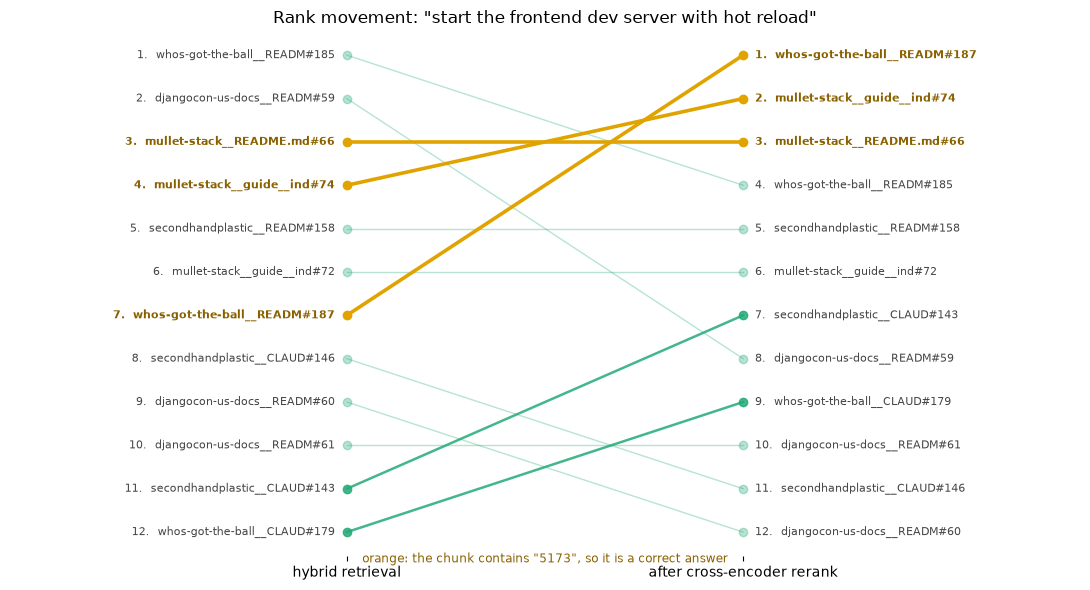

In [9]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(query, idxs):
    scores = reranker.predict([(query, chunks[i]["text"]) for i in idxs])
    return [i for _, i in sorted(zip(scores, idxs), key=lambda p: -p[0])]

def hybrid_reranked(query, k=5, pool=25):
    return rerank(query, hybrid(query, k=pool, pool=pool))[:k]

q = "start the frontend dev server with hot reload"
before = hybrid(q, k=12, pool=12)
figures.rank_movement(q, before, rerank(q, before), chunks, marker="5173")

*In production:* Cohere Rerank, `bge-reranker-v2-m3`, or Voyage rerank.

Orange marks the chunks that mention port 5173, which is what a correct answer needs here.
Fusion left them at ranks 3, 4 and 7; the reranker moved all three to the top. Same
candidates, better order, and that matters because the prompt has room for about three
chunks rather than twenty-five.

## 5. Does any of it work?

Everything above is a plausible story, and none of it is evidence. An eval turns "this
feels better" into a number, and it works like a test suite: write down what the right
answer is, then count how often you get it.

The labelling here is deliberately blunt. `queries.json` holds 18 questions, each with a
**marker**: the exact string that has to appear in a retrieved chunk for the search to
count as correct.

```
question: "how do I wipe my local database and start over?"
marker:   "make reset"
```

Getting labels is the expensive part of evaluating retrieval, which is why so many demos
stop before it. It is cheap here only because the corpus is 13 files I wrote.

In [10]:
import json

queries = json.loads(pathlib.Path("queries.json").read_text())

def evaluate(retrieve, k=5):
    hits, rr = 0, []
    for item in queries:
        got = [chunks[i]["text"] for i in retrieve(item["q"], k)]
        ranks = [r for r, text in enumerate(got, 1) if item["marker"] in text]
        hits += bool(ranks)
        rr.append(1 / ranks[0] if ranks else 0.0)
    return hits / len(queries), float(np.mean(rr))

methods = {
    "by meaning":      lambda q, k: top_k(dense_scores(q), k),
    "by keyword":      lambda q, k: top_k(bm25_scores(q), k),
    "both, fused":     hybrid,
    "fused + rerank":  hybrid_reranked,
}
results = {name: evaluate(fn) for name, fn in methods.items()}
for name, (r, m) in results.items():
    print(f"{name:<16} recall@5 {r:.2f}   MRR {m:.2f}")

by meaning       recall@5 0.78   MRR 0.69
by keyword       recall@5 0.78   MRR 0.62
both, fused      recall@5 0.89   MRR 0.65
fused + rerank   recall@5 0.94   MRR 0.85


**recall@5** is the fraction of questions whose answer appeared anywhere in the top 5.
**MRR** adds *how high*: 1 if the right chunk came first, 1/2 if second, 1/3 if third, 0 if
it never appeared, averaged over the questions.

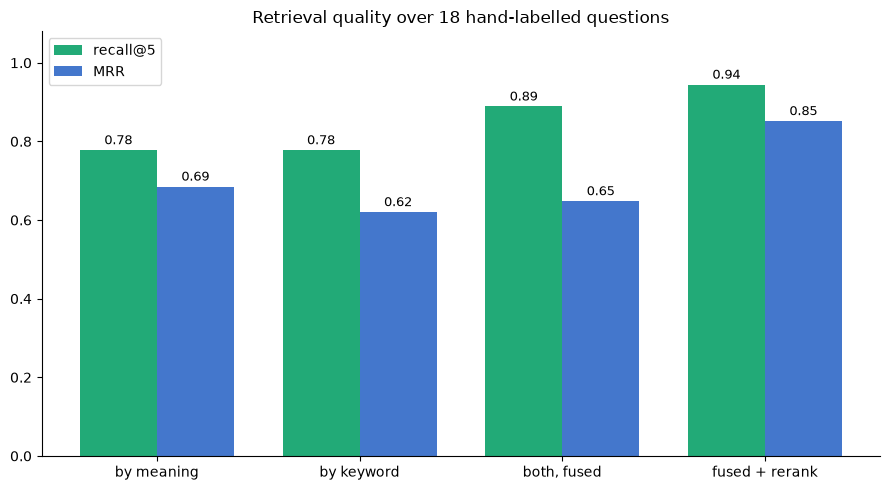

In [11]:
figures.retrieval_quality(results, len(queries))

The two search methods tie at 0.78 and fail on different questions, which is what makes
fusing them worth anything. Fusion then lifts recall to 0.89 while MRR drops to 0.65: it
gets the right chunk into the top 5 without knowing which of the five is best. The
reranker takes that same set and fixes the order, 0.65 to 0.85.

An eval earns its keep by catching a change that made things worse. Say you decide smaller
chunks would be more precise and drop the size from 900 characters to 200. One word, it
runs without error, and every answer still looks plausible.

In [12]:
before = evaluate(hybrid)[0]

chunks = build_chunks(max_chars=200, overlap=30)     # the "improvement"
E = embed([c["text"] for c in chunks])
index_bm25(chunks)
after = evaluate(hybrid)[0]

chunks = build_chunks()                              # put it back
E = embed([c["text"] for c in chunks])
index_bm25(chunks)

print(f"chunk size 900 -> recall@5 {before:.2f}")
print(f"chunk size 200 -> recall@5 {after:.2f}")
print(f"verdict: {'REGRESSION' if after < before else 'fine'}, "
      f"{(before-after)*len(queries):.0f} of {len(queries)} questions newly broken")

chunk size 900 -> recall@5 0.89
chunk size 200 -> recall@5 0.78
verdict: REGRESSION, 2 of 18 questions newly broken


That is the argument for evals in one cell. Two caveats worth saying out loud: with 18
questions each is worth 0.06 recall, so this can say "200 is a bad idea" but cannot referee
0.89 against 0.94. And it measures retrieval only, which is the half you can check without
a language model.

*In production:* RAGAS, which scores the generated answer as well. That needs a language
model to grade, so it costs money per run.

## 6. The decisions that actually matter

Retrieval quality is mostly decided by things that are not models.

**Where you cut.** The regression above was a chunking change, not a model change. Below is
what the windowing does to a long section, with the overlap in orange so a fact sitting on
a cut line survives whole somewhere.

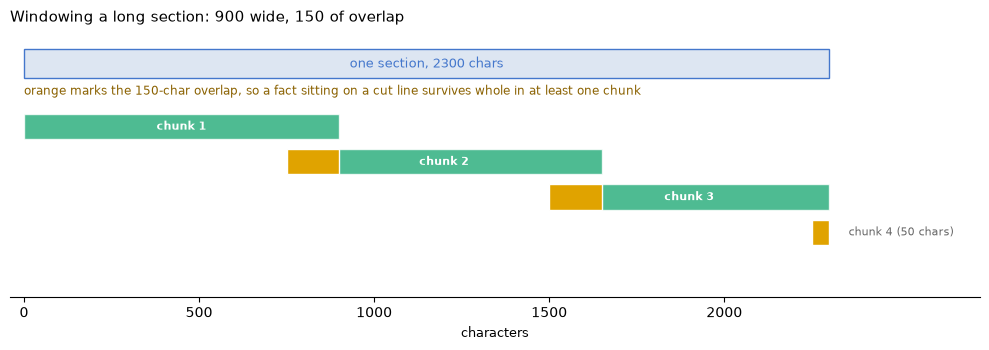

In [13]:
figures.chunk_windows(sec_len=2300, max_chars=900, overlap=150)

**Questions with no single answer.** Two unrelated projects in this corpus run a dev server
on port 5173, so "start the frontend dev server" has several correct answers and no way to
choose between them. No reranker fixes that. The fix is metadata filtering: scope the
search to one project, which is a `WHERE` clause rather than a better model.

**Staleness.** The embeddings were computed once, and the moment anyone edits a document
they are out of date. Re-embedding everything is fast here and slow and expensive on a real
corpus, so production systems re-embed only what changed. That needs each chunk to have a
stable identity, and hashing its text works.

In [14]:
import hashlib

def chunk_id(c):
    return hashlib.sha256(c["text"].encode()).hexdigest()[:12]

index = {chunk_id(c): c for c in chunks}      # what is already embedded

edited = build_chunks()                        # pretend one file just changed
edited[7] = {**edited[7], "text": edited[7]["text"] + " A sentence someone just added."}

fresh = [c for c in edited if chunk_id(c) not in index]
gone  = set(index) - {chunk_id(c) for c in edited}

print(f"{len(edited)} chunks, {len(fresh)} need embedding, {len(gone)} to delete")
print(f"saved: {(1 - len(fresh)/len(edited)) * 100:.0f}% of the embedding work")

199 chunks, 1 need embedding, 1 to delete
saved: 99% of the embedding work


Hashing handles the awkward case for free: edit one paragraph and the chunks around it
shift, so their text changes and their hashes change with them. Keyword search has to be
rebuilt regardless, because document frequency is a corpus-wide statistic.

The one that catches people: **changing the embedding model means re-embedding everything.**
Vectors from two models are not comparable, so there is no incremental path. A
half-migrated index returns nonsense rather than failing loudly, so store the model name
beside the vectors and the mismatch is at least detectable.

## 7. The generation half

The G in RAG is one request with the retrieved text in the prompt. There is no API call
here, which is partly the point: retrieval is where the engineering lives, and it can be
measured without a language model in the loop.

In [15]:
question = "why is the rate limiter backed by the database instead of kept in memory?"
picked   = hybrid_reranked(question, k=3)

def sources(trim=None):
    out = []
    for i in picked:
        text = chunks[i]["text"]
        if trim:                       # one-line view, for reading on screen
            text = " ".join(text.split())[:trim] + " ..."
        out.append(f"[source: {chunks[i]['file']}]\n{text}")
    return "\n\n---\n\n".join(out)

def assemble(body):
    return "\n".join([
        "Answer the question using only the sources below.",
        "Cite the source filename for each claim.",
        "If the sources do not contain the answer, say so instead of guessing.",
        "",
        "SOURCES:",
        body,
        "",
        f"QUESTION: {question}",
    ])

prompt = assemble(sources())           # the real thing, chunks in full
print(f"[{len(prompt)} characters. Below, the sources are cut short so the shape shows.]")
print()
print(assemble(sources(trim=140)))

[2896 characters. Below, the sources are cut short so the shape shows.]

Answer the question using only the sources below.
Cite the source filename for each claim.
If the sources do not contain the answer, say so instead of guessing.

SOURCES:
[source: secondhandplastic__README.md]
### Why the pooler Zero-downtime deploys run old and new instances at once, and Supabase's direct connection allows far too few connections  ...

---

[source: secondhandplastic__CLAUDE.md]
## Platform constraints that shape the code - **No persistent volumes.** Anything written to local disk is lost on redeploy. State lives in  ...

---

[source: whos-got-the-ball__README.md]
## Could it drop into an existing system? The backend is intentionally a thin layer over three tables, which makes a few interop paths reali ...

QUESTION: why is the rate limiter backed by the database instead of kept in memory?


*In production:* one `client.messages.create` call with that string as the user message.

Each of those three instructions prevents a specific failure. **"Using only the sources"**
keeps the answer tied to what you retrieved, since otherwise the model answers from
pretraining and hides retrieval failures. **"Cite the filename"** makes claims checkable.
**"Say so instead of guessing"** gives the model an exit, because a confident wrong answer
is worse than "I don't know."

Good retrieval does not guarantee a good answer. The right chunk can be in the prompt and
the model still gets it wrong, which is why RAG evaluation has a second half called
**faithfulness**: is every claim in the answer supported by the retrieved text? Scoring
that needs a second model, so it is named here rather than built.

## Where to go next

Four terms worth recognising when you meet them, roughly in order of how much they would
move the numbers on a corpus like this one.

- **Contextual retrieval**: prefix each chunk with a sentence saying where it came from
  before embedding it, which fixes the chunk cut from the middle of a file that no longer
  makes sense alone.
- **Metadata filtering**: the `WHERE` clause from section 6.
- **Query rewriting**: expand the question before searching, so "how do I run this" gains
  some content words.
- **Late interaction (ColBERT)**: a vector per token rather than per chunk. Close to
  cross-encoder quality at closer to embedding speed.

One more piece of framing, since it connects this to how the models themselves work. The
operation at the heart of a transformer, **attention**, is also a search: every word scores
itself against every other word, and ends up holding a blend of whatever was relevant. RAG
is the same shape, over a store too large to fit in the context window, and with a hard cut
instead of a blend. Keep the top few, drop the rest.

## The short version

Almost none of the work is in the vector math. It is in cutting documents sensibly, running
keyword search alongside semantic search, and writing down enough labelled questions to
have a number to point at when someone proposes a change.